# LSTM + GNN Flood Forecasting Model
Predicts streamflow 24 hours ahead at 37 primary gauge sites.

**Data Source:**
- `raw-streamflow-15min` — (all 49 sites) for computing edge attributes (lag, scale, R²) via `analyze_gauge_relationship`

Edge attributes are computed once, then frozen for training.

In [7]:
"""
GNN Flood Forecasting Model
Predicts streamflow using the top 37 high flood-severity sites.
"""
import numpy as np
import tensorflow as tf
import torch
from tensorflow.keras.callbacks import EarlyStopping
import json
import polars as pl

from src.preprocessing.preprocessing import processor, TorchStandardScaler, train_val_test_split_by_time
from src.models.lstm import LSTMModel
from src.utils.helpers import create_sequences

In [8]:
def get_all_sites(upstream_pair_dict: dict):
    """
    Derive the complete site list from the upstream_pair_dict.

    Returns
    -------
    all_sites      : sorted list of all unique site IDs (primary + upstream-only)
    primary_sites  : the 37 primary site IDs (keys of the dict)
    upstream_only  : site IDs that appear only as upstream values (12 sites)
    """
    primary_sites   = list(upstream_pair_dict.keys())
    upstream_values = {v for v in upstream_pair_dict.values() if v is not None}
    upstream_only   = sorted(upstream_values - set(primary_sites))
    all_sites       = sorted(set(primary_sites) | upstream_values)
    return all_sites, primary_sites, upstream_only

In [9]:
with open("../../../src/utils/upstream_pair_dict.json") as f:
    upstream_pair_dict = json.load(f)

all_sites, primary_sites, upstream_only = get_all_sites(upstream_pair_dict)
print(f"Primary        : {len(primary_sites)}")
print(f"Upstream-only  : {len(upstream_only)}")
print(f"Total          : {len(all_sites)}")

Primary        : 37
Upstream-only  : 12
Total          : 49


In [10]:
import wandb
import os

api          = wandb.Api()
artifact     = api.artifact("flood-forecasting/raw-streamflow-15min:latest")
artifact_dir = artifact.download()
parquet_path = os.path.join(artifact_dir, "streamflow_15min", "*.parquet")

SENTINEL = -999_999

df_49_hourly = (
    pl.scan_parquet(parquet_path)
    .filter(pl.col("site_id").is_in(all_sites))
    .select(["site_id", "datetime", "streamflow_cfs"])
    .with_columns(
        pl.when(pl.col("streamflow_cfs") == SENTINEL)
        .then(None)
        .otherwise(pl.col("streamflow_cfs"))
        .alias("streamflow_cfs")
    )
    .with_columns(
        pl.col("datetime").dt.truncate("1h").alias("datetime")
    )
    .group_by(["site_id", "datetime"])
    .agg(
        pl.col("streamflow_cfs").max().alias("streamflow_cfs_max")
    )
    .sort(["site_id", "datetime"])
    .collect()
)

print(f"Shape          : {df_49_hourly.shape}")
print(f"Unique sites   : {df_49_hourly['site_id'].n_unique()}")
print(f"Date range     : {df_49_hourly['datetime'].min()} → {df_49_hourly['datetime'].max()}")
print(f"Null streamflow: {df_49_hourly['streamflow_cfs_max'].null_count():,}")
print(df_49_hourly.head())

wandb: Downloading large artifact 'raw-streamflow-15min:latest', 1467.48MB. 20 files...
wandb:   20 of 20 files downloaded.  
Done. 00:00:00.3 (4483.6MB/s)


Shape          : (6978847, 3)
Unique sites   : 49
Date range     : 2007-10-01 05:00:00+00:00 → 2026-02-01 17:00:00+00:00
Null streamflow: 732,981
shape: (5, 3)
┌──────────┬─────────────────────────┬────────────────────┐
│ site_id  ┆ datetime                ┆ streamflow_cfs_max │
│ ---      ┆ ---                     ┆ ---                │
│ str      ┆ datetime[μs, UTC]       ┆ f64                │
╞══════════╪═════════════════════════╪════════════════════╡
│ 06027600 ┆ 2008-07-01 06:00:00 UTC ┆ 4220.0             │
│ 06027600 ┆ 2008-07-01 07:00:00 UTC ┆ 4220.0             │
│ 06027600 ┆ 2008-07-01 08:00:00 UTC ┆ 4260.0             │
│ 06027600 ┆ 2008-07-01 09:00:00 UTC ┆ 4220.0             │
│ 06027600 ┆ 2008-07-01 10:00:00 UTC ┆ 4180.0             │
└──────────┴─────────────────────────┴────────────────────┘


In [15]:
def chronological_split_by_chunk(
    df: pl.DataFrame,
    time_col: str,
    train_frac: float,
    val_frac: float,
    split_time_days: int,
) -> tuple[pl.DataFrame, pl.DataFrame, pl.DataFrame]:
    """
    Rolling chunk split implemented in Polars.
    Assigns train/val/test labels per chunk of split_time_days,
    then joins back to the full DataFrame in one pass.
    """
    dates   = df[time_col].unique().sort()
    n       = len(dates)
    labels  = []

    for start in range(0, n, split_time_days):
        chunk   = dates[start : start + split_time_days]
        n_chunk = len(chunk)
        if n_chunk < 10:
            continue

        train_end = int(n_chunk * train_frac)
        val_end   = int(n_chunk * val_frac)

        labels.extend([("train", d) for d in chunk[:train_end].to_list()])
        labels.extend([("val",   d) for d in chunk[train_end:val_end].to_list()])
        labels.extend([("test",  d) for d in chunk[val_end:].to_list()])

    split_label_df = pl.DataFrame(
        {"split": [l[0] for l in labels], time_col: [l[1] for l in labels]},
        schema={"split": pl.Utf8, time_col: df[time_col].dtype},
    )

    df_labeled = df.join(split_label_df, on=time_col, how="inner")

    train_df = df_labeled.filter(pl.col("split") == "train").drop("split")
    val_df   = df_labeled.filter(pl.col("split") == "val").drop("split")
    test_df  = df_labeled.filter(pl.col("split") == "test").drop("split")

    return train_df, val_df, test_df

In [16]:
def preprocess_hourly(df: pl.DataFrame, config: dict):
    TARGET_COL   = config["target"]
    SHIFT_AMOUNT = 24                          # 24h ahead at hourly resolution
    FEATURE_COLS = ["streamflow_cfs_max"]      # updated column name

    # Fill nulls with site mean before anything else
    df = df.with_columns(
        pl.col("streamflow_cfs_max")
        .fill_null(pl.col("streamflow_cfs_max").mean().over("site_id"))
    )

    # Sort and create target
    df = (
        df
        .sort(["site_id", "datetime"])
        .with_columns(
            pl.col("streamflow_cfs_max")
            .shift(-SHIFT_AMOUNT)
            .over("site_id")
            .alias(TARGET_COL)
        )
        .drop_nulls(subset=[TARGET_COL])
    )

    # Chronological split
    if config.get("split_time_days") is None:
        times     = df["datetime"].unique().sort()
        n         = len(times)
        train_end = times[int(n * config["train_split"])]
        val_end   = times[int(n * config["val_split"])]

        train_df = df.filter(pl.col("datetime") <  train_end)
        val_df   = df.filter((pl.col("datetime") >= train_end) & (pl.col("datetime") < val_end))
        test_df  = df.filter(pl.col("datetime") >= val_end)
    else:
        train_df, val_df, test_df = chronological_split_by_chunk(
            df,
            time_col        = "datetime",
            train_frac      = config["train_split"],
            val_frac        = config["val_split"],
            split_time_days = config["split_time_days"],
        )

    print(f"Train: {train_df.shape[0]:,} | Val: {val_df.shape[0]:,} | Test: {test_df.shape[0]:,}")
    del df

    # Fit scalers on train only
    feature_scaler = TorchStandardScaler()
    target_scaler  = TorchStandardScaler()

    feature_scaler.fit(torch.tensor(train_df.select(FEATURE_COLS).to_numpy(), dtype=torch.float32))
    target_scaler.fit(torch.tensor(train_df[TARGET_COL].to_numpy(),           dtype=torch.float32).reshape(-1, 1))

    def make_split(split_df):
        X_raw = torch.tensor(split_df.select(FEATURE_COLS).to_numpy(), dtype=torch.float32)
        y_raw = torch.tensor(split_df[TARGET_COL].to_numpy(),           dtype=torch.float32).reshape(-1, 1)

        X_scaled = feature_scaler.transform(X_raw).numpy().astype(np.float32)
        y_scaled = target_scaler.transform(y_raw).numpy().astype(np.float32)
        del X_raw, y_raw

        X_df = pl.concat([
            split_df.select(["site_id", "datetime"]),
            pl.DataFrame(X_scaled, schema=FEATURE_COLS),
        ], how="horizontal")
        y_df = pl.DataFrame(y_scaled, schema=[TARGET_COL])
        return X_df, y_df

    train_X, train_y = make_split(train_df); del train_df
    val_X,   val_y   = make_split(val_df);   del val_df
    test_X,  test_y  = make_split(test_df);  del test_df

    return {
        "train_X": train_X, "val_X": val_X, "test_X": test_X,
        "train_y": train_y, "val_y": val_y, "test_y": test_y,
        "feature_scaler": feature_scaler,
        "target_scaler":  target_scaler,
    }

In [17]:
config = {
    "target":          "streamflow_cfs_target_24h",
    "train_split":     0.8,
    "val_split":       0.9,
    "split_time_days": 70,
}

outputs       = preprocess_hourly(df_49_hourly, config)
train_X       = outputs["train_X"]
val_X         = outputs["val_X"]
test_X        = outputs["test_X"]
train_y       = outputs["train_y"]
val_y         = outputs["val_y"]
test_y        = outputs["test_y"]
target_scaler = outputs["target_scaler"]

Train: 5,581,586 | Val: 698,006 | Test: 698,079


In [18]:
from scipy.signal import correlate
from sklearn.linear_model import LinearRegression

def analyze_gauge_relationship(
    df: pl.DataFrame,
    primary_site_id: str,
    upstream_site_id: str,
    max_lag_steps: int = 72,   
) -> dict:
    """
    Compute edge attributes for one upstream→downstream gauge pair.

    Parameters
    ----------
    df              : df_49_hourly
    primary_site_id : downstream gauge
    upstream_site_id: upstream gauge
    max_lag_steps   : maximum lag to search in timesteps (default 72h)

    Returns
    -------
    dict with keys: lag_steps, scale_m, intercept_b, r_squared
    """
    df_pair = (
        df
        .filter(pl.col("site_id").is_in([primary_site_id, upstream_site_id]))
        .pivot(index="datetime", on="site_id", values="streamflow_cfs_max")
        .sort("datetime")
        .rename({primary_site_id: "primary", upstream_site_id: "upstream"})
    )

    df_overlap = df_pair.filter(
        pl.col("primary").is_not_null() & pl.col("upstream").is_not_null()
    )

    if df_overlap.height < 2:
        raise ValueError(
            f"Insufficient overlap for {primary_site_id} ← {upstream_site_id} "
            f"(n={df_overlap.height})"
        )

    primary_vals  = df_overlap["primary"].to_numpy()
    upstream_vals = df_overlap["upstream"].to_numpy()

    # Cross-correlation to find best lag
    full_corr  = correlate(
        primary_vals  - primary_vals.mean(),
        upstream_vals - upstream_vals.mean(),
        mode="full"
    )
    lags       = np.arange(-len(upstream_vals) + 1, len(primary_vals))
    valid_mask = (lags >= 0) & (lags <= max_lag_steps)
    best_lag_steps = int(lags[valid_mask][np.argmax(full_corr[valid_mask])])

    # Align by lag then fit linear model
    if best_lag_steps > 0:
        u_shifted = upstream_vals[:-best_lag_steps]
        p_aligned = primary_vals[best_lag_steps:]
    else:
        u_shifted = upstream_vals
        p_aligned = primary_vals

    reg = LinearRegression().fit(u_shifted.reshape(-1, 1), p_aligned)

    return {
        "lag_steps":   best_lag_steps,
        "scale_m":     float(reg.coef_[0]),
        "intercept_b": float(reg.intercept_),
        "r_squared":   float(reg.score(u_shifted.reshape(-1, 1), p_aligned)),
    }

In [20]:
print(f"{'Upstream':<12} → {'Primary':<12}  {'lag_steps':>10}  {'scale_m':>8}  {'intercept_b':>13}  {'R²':>6}")
print("-" * 68)

edge_results = {}
for primary_id, upstream_id in upstream_pair_dict.items():
    if upstream_id is None:
        continue
    try:
        r = analyze_gauge_relationship(df_49_hourly, primary_id, upstream_id)
        edge_results[(primary_id, upstream_id)] = r
        print(f"{upstream_id:<12} → {primary_id:<12}  "
              f"{r['lag_steps']:>10}  "
              f"{r['scale_m']:>8.4f}  "
              f"{r['intercept_b']:>13.2f}  "
              f"{r['r_squared']:>6.4f}")
    except ValueError as e:
        print(f"{upstream_id:<12} → {primary_id:<12}  SKIPPED — {e}")

print(f"\nEdge attributes ready for {len(edge_results)} pairs.")

Upstream     → Primary        lag_steps   scale_m    intercept_b      R²
--------------------------------------------------------------------
06803495     → 06803500               0    1.0478          33.08  0.9944
06447500     → 06446700               0    1.0798          -9.58  0.6746
06790500     → 06793000               2    2.6344       -1971.70  0.6729
06820410     → 06820500              17    1.4624         559.20  0.6380
06803486     → 06803495               0    2.7651          26.26  0.6037
06027600     → 06036650               3    1.1916         124.69  0.9897
06209500     → 06207500               4    7.5869        -159.72  0.7382
06803500     → 06803513               1    1.0524          26.47  0.9768
06062500     → 06061500               7    1.0064          27.09  0.8112
06799000     → 06799315               6    1.6440         -14.36  0.8306
06880800     → 06881000               9    2.1365         110.84  0.6991
06917000     → 06917060              23    0.9870      

In [21]:
from torch_geometric.data import Data

node_id_to_index = {site: idx for idx, site in enumerate(sorted(all_sites))}

sources, targets, attr_rows = [], [], []

for primary_id, upstream_id in upstream_pair_dict.items():
    if upstream_id is None:
        continue
    key = (primary_id, upstream_id)
    if key not in edge_results:
        print(f"Warning: no edge attr for {upstream_id} → {primary_id}, skipping.")
        continue
    r = edge_results[key]
    sources.append(node_id_to_index[upstream_id])
    targets.append(node_id_to_index[primary_id])
    attr_rows.append([r["lag_steps"], r["scale_m"], r["intercept_b"], r["r_squared"]])

edge_index   = torch.tensor([sources, targets], dtype=torch.long)
edge_attr    = torch.tensor(attr_rows,          dtype=torch.float32)
primary_mask = torch.tensor(
    [s in set(primary_sites) for s in sorted(all_sites)],
    dtype=torch.bool
)

graph = Data(
    edge_index   = edge_index,
    edge_attr    = edge_attr,
    primary_mask = primary_mask,
    num_nodes    = len(all_sites),
)

print(f"Nodes         : {graph.num_nodes}")
print(f"Edges         : {edge_index.shape[1]}")
print(f"Edge attr     : {edge_attr.shape}  [lag_steps, scale_m, intercept_b, r_squared]")
print(f"Primary nodes : {primary_mask.sum().item()}")

c:\Users\mroth\Comp 549\Flood-Forecasting\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Nodes         : 49
Edges         : 16
Edge attr     : torch.Size([16, 4])  [lag_steps, scale_m, intercept_b, r_squared]
Primary nodes : 37


In [22]:
WINDOW_SIZE = 72   # 72 hours

# Size check before allocating
n_times      = train_X.filter(pl.col("site_id") == primary_sites[0]).shape[0]
n_windows    = n_times - WINDOW_SIZE
tensor_gb    = n_windows * len(all_sites) * WINDOW_SIZE * 1 * 4 / 1e9
print(f"Approx windows per split : {n_windows:,}")
print(f"Train tensor size        : ~{tensor_gb:.2f} GB")

Approx windows per split : 127,034
Train tensor size        : ~1.79 GB


In [23]:
max_lag = max(r["lag_steps"] for r in edge_results.values())
print(f"Max lag steps across all pairs : {max_lag}")
print(f"Max lag hours                  : {max_lag:.1f} hrs")

Max lag steps across all pairs : 23
Max lag hours                  : 23.0 hrs


In [24]:
for ws in [24, 48, 72, 96]:
    n_windows = n_times - ws
    gb = n_windows * len(all_sites) * ws * 1 * 4 / 1e9
    print(f"WINDOW_SIZE={ws:>4} ({ws:>4}h)  →  {gb:.2f} GB")

WINDOW_SIZE=  24 (  24h)  →  0.60 GB
WINDOW_SIZE=  48 (  48h)  →  1.20 GB
WINDOW_SIZE=  72 (  72h)  →  1.79 GB
WINDOW_SIZE=  96 (  96h)  →  2.39 GB


In [25]:
node_stack_gb = (train_X.shape[0] + val_X.shape[0] + test_X.shape[0]) * 49 * 1 * 4 / 1e9
print(f"Node stack memory (all splits) : {node_stack_gb:.2f} GB")

Node stack memory (all splits) : 1.37 GB


In [26]:
from torch.utils.data import Dataset

class StreamflowGraphDataset(Dataset):
    def __init__(self, X_df, y_df, all_sites, primary_sites, window_size, target_col):
        ordered_sites = sorted(all_sites)
        primary_order = sorted(primary_sites)
        feature_cols  = [c for c in X_df.columns if c not in ("site_id", "datetime")]

        y_df_aligned = pl.concat([
            X_df.select(["site_id", "datetime"]),
            y_df
        ], how="horizontal")

        # Build per-node feature arrays, track which sites have data
        node_list    = []
        site_lengths = []
        self.valid_primary_mask = []   # True = site has data in this split

        for site in ordered_sites:
            arr = (
                X_df
                .filter(pl.col("site_id") == site)
                .sort("datetime")
                .select(feature_cols)
                .to_numpy()
                .astype(np.float32)
            )
            arr = np.nan_to_num(arr, nan=0.0)
            node_list.append(arr)
            site_lengths.append(arr.shape[0])

        # Find min length across sites that actually have data
        valid_lengths = [l for l in site_lengths if l > 0]
        min_T         = max(min(valid_lengths), window_size + 1)

        # Fill missing sites with zeros
        node_list_fixed = []
        for i, arr in enumerate(node_list):
            n_features = 1  # streamflow_cfs only
            if arr.shape[0] == 0:
                print(f"Warning: {ordered_sites[i]} has 0 rows in this split — filling with zeros.")
                node_list_fixed.append(np.zeros((min_T, n_features), dtype=np.float32))
            elif arr.shape[0] < min_T:
                pad = min_T - arr.shape[0]
                node_list_fixed.append(np.concatenate([
                    arr,
                    np.zeros((pad, arr.shape[1]), dtype=np.float32)
                ], axis=0))
            else:
                node_list_fixed.append(arr[:min_T])

        self.node_stack = np.stack(node_list_fixed, axis=1)  # [T, N, F]

        # Build target arrays, track valid primary sites
        target_list = []
        for site in primary_order:
            site_y = (
                y_df_aligned
                .filter(pl.col("site_id") == site)
                .sort("datetime")[target_col]
                .to_numpy()
                .astype(np.float32)
            )
            has_data = len(site_y) > 0
            self.valid_primary_mask.append(has_data)

            if not has_data:
                site_y = np.zeros(min_T, dtype=np.float32)
            elif len(site_y) < min_T:
                pad    = min_T - len(site_y)
                site_y = np.concatenate([site_y, np.zeros(pad, dtype=np.float32)])
            target_list.append(site_y[:min_T])

        self.valid_primary_mask = torch.tensor(self.valid_primary_mask, dtype=torch.bool)
        self.target_stack = np.stack(target_list, axis=1)  # [T, P]
        self.window_size  = window_size
        self.n_windows    = min_T - window_size

    def __len__(self):
        return self.n_windows

    def __getitem__(self, i):
        X = self.node_stack[i : i + self.window_size].transpose(1, 0, 2)
        y = self.target_stack[i + self.window_size]
        return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [27]:
from torch.utils.data import Dataset, DataLoader

WINDOW_SIZE = 72

print("Building datasets...")
train_ds = StreamflowGraphDataset(train_X, train_y, all_sites, primary_sites, WINDOW_SIZE, config["target"])
val_ds   = StreamflowGraphDataset(val_X,   val_y,   all_sites, primary_sites, WINDOW_SIZE, config["target"])
test_ds  = StreamflowGraphDataset(test_X,  test_y,  all_sites, primary_sites, WINDOW_SIZE, config["target"])

print(f"Train windows : {len(train_ds):,}")
print(f"Val   windows : {len(val_ds):,}")
print(f"Test  windows : {len(test_ds):,}")

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  drop_last=True, num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=0)

Building datasets...
Train windows : 42,263
Val   windows : 5,192
Test  windows : 5,210


In [28]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATv2Conv

class StreamflowGNN(nn.Module):
    def __init__(
        self,
        num_dynamic_features: int,
        num_static_features:  int = 0,
        hidden_dim:  int   = 64,
        lstm_layers: int   = 2,
        gat_heads:   int   = 4,
        gat_layers:  int   = 2,
        dropout:     float = 0.3,
    ):
        super().__init__()

        self.hidden_dim = hidden_dim

        # Temporal encoder
        self.lstm = nn.LSTM(
            input_size  = num_dynamic_features,
            hidden_size = hidden_dim,
            num_layers  = lstm_layers,
            batch_first = True,
            dropout     = dropout if lstm_layers > 1 else 0.0,
        )

        # Static fusion — only built if static features exist
        if num_static_features > 0:
            self.static_proj = nn.Sequential(
                nn.Linear(num_static_features, hidden_dim),
                nn.ReLU(),
            )
            self.fusion = nn.Sequential(
                nn.Linear(hidden_dim * 2, hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            )
        else:
            self.static_proj = None
            self.fusion      = None

        # Spatial encoder
        self.gat_convs = nn.ModuleList()
        self.gat_norms = nn.ModuleList()
        for _ in range(gat_layers):
            self.gat_convs.append(
                GATv2Conv(
                    in_channels    = hidden_dim,
                    out_channels   = hidden_dim,
                    heads          = gat_heads,
                    edge_dim       = 4,   # lag_steps, scale_m, intercept_b, r_squared
                    concat         = False,
                    dropout        = dropout,
                    add_self_loops = True,
                )
            )
            self.gat_norms.append(nn.LayerNorm(hidden_dim))

        # Per-node gate: blends GNN and LSTM branches
        self.gate_fc = nn.Linear(hidden_dim, 1)

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),
            nn.Linear(hidden_dim // 2, 1),
        )

        self._train_losses = []
        self._val_losses   = []

    def forward(self, x_seq, edge_index, edge_attr, primary_mask, x_static=None):
        # 1. Temporal encoding
        lstm_out, _ = self.lstm(x_seq)
        h_lstm      = lstm_out[:, -1, :]          # [num_nodes, hidden_dim]

        # 2. Static fusion (skipped if no static features)
        if x_static is not None and self.static_proj is not None:
            h_static = self.static_proj(x_static)
            h        = self.fusion(torch.cat([h_lstm, h_static], dim=-1))
        else:
            h = h_lstm

        # 3. Spatial message passing
        h_gnn = h
        for conv, norm in zip(self.gat_convs, self.gat_norms):
            h_new = F.elu(conv(h_gnn, edge_index, edge_attr))
            h_gnn = norm(h_gnn + h_new)

        # 4. Per-node gate
        gate    = torch.sigmoid(self.gate_fc(h_lstm))
        h_fused = gate * h_gnn + (1 - gate) * h_lstm

        # 5. Decode at primary nodes only
        return self.decoder(h_fused[primary_mask])

## Smoke Test

In [29]:
gnn = StreamflowGNN(
    num_dynamic_features = 1,
    num_static_features  = 0,
    hidden_dim  = 32,
    lstm_layers = 1,
    gat_heads   = 2,
    gat_layers  = 2,
    dropout     = 0.3,
)

total_params = sum(p.numel() for p in gnn.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

sample_X, sample_y = train_ds[0]
pred = gnn(
    x_seq        = sample_X,
    edge_index   = graph.edge_index,
    edge_attr    = graph.edge_attr,
    primary_mask = graph.primary_mask,
)
print(f"Input shape        : {sample_X.shape}")   # [49, 72, 1]
print(f"Forward pass output: {pred.shape}")        # [37, 1]

Trainable parameters: 14,338
Input shape        : torch.Size([49, 72, 1])
Forward pass output: torch.Size([37, 1])


## Training

In [30]:
# ---- Timing estimate ----
import time

gnn.eval()
X_batch, y_batch = next(iter(train_loader))

start = time.time()
batch_preds = []
for b in range(X_batch.shape[0]):
    pred = gnn(
        x_seq        = X_batch[b],
        edge_index   = graph.edge_index,
        edge_attr    = graph.edge_attr,
        primary_mask = graph.primary_mask,
    )
    batch_preds.append(pred)
elapsed = time.time() - start

batches_per_epoch = len(train_loader)
print(f"Single batch time  : {elapsed:.2f}s")
print(f"Estimated per epoch: {elapsed * batches_per_epoch / 60:.1f} mins")
print(f"Estimated 20 epochs: {elapsed * batches_per_epoch * 20 / 3600:.1f} hrs")

Single batch time  : 0.13s
Estimated per epoch: 2.9 mins
Estimated 20 epochs: 1.0 hrs


In [31]:
optimizer = torch.optim.Adam(gnn.parameters(), lr=1e-3, weight_decay=1e-5)

best_val_loss    = float("inf")
patience_counter = 0
patience         = 5
best_state_dict  = None
EPOCHS           = 20

for epoch in range(1, EPOCHS + 1):

    # ---- Train ----
    gnn.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        batch_preds = []
        for b in range(X_batch.shape[0]):
            pred = gnn(
                x_seq        = X_batch[b],           # [49, 72, 1]
                edge_index   = graph.edge_index,
                edge_attr    = graph.edge_attr,
                primary_mask = graph.primary_mask,
            )
            batch_preds.append(pred)

        preds = torch.stack(batch_preds, dim=0).squeeze(-1)   # [B, 37]
        loss  = F.mse_loss(
            preds[:, train_ds.valid_primary_mask],
            y_batch[:, train_ds.valid_primary_mask],
        )
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gnn.parameters(), max_norm=1.0)
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ---- Validate ----
    gnn.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            batch_preds = []
            for b in range(X_batch.shape[0]):
                pred = gnn(
                    x_seq        = X_batch[b],
                    edge_index   = graph.edge_index,
                    edge_attr    = graph.edge_attr,
                    primary_mask = graph.primary_mask,
                )
                batch_preds.append(pred)

            preds     = torch.stack(batch_preds, dim=0).squeeze(-1)
            val_loss += F.mse_loss(
                preds[:, val_ds.valid_primary_mask],
                y_batch[:, val_ds.valid_primary_mask],
            ).item()

    val_loss /= len(val_loader)

    gnn._train_losses.append(train_loss)
    gnn._val_losses.append(val_loss)

    print(f"Epoch {epoch:>3}/{EPOCHS}  train={train_loss:.6f}  val={val_loss:.6f}")

    # ---- Early stopping ----
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        best_state_dict  = {k: v.clone() for k, v in gnn.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch} (best val={best_val_loss:.6f})")
            break

if best_state_dict:
    gnn.load_state_dict(best_state_dict)
    print("Restored best weights.")

Epoch   1/20  train=0.272078  val=0.301906
Epoch   2/20  train=0.224052  val=0.300984
Epoch   3/20  train=0.217019  val=0.325916
Epoch   4/20  train=0.213031  val=0.309543
Epoch   5/20  train=0.209504  val=0.318686
Epoch   6/20  train=0.207767  val=0.312064
Epoch   7/20  train=0.204850  val=0.303938

Early stopping at epoch 7 (best val=0.300984)
Restored best weights.


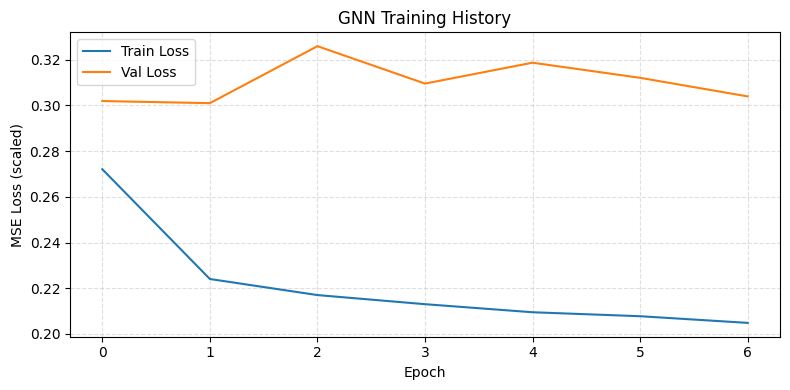

In [32]:
import matplotlib.pyplot as plt

# Plot training history
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(gnn._train_losses, label="Train Loss")
ax.plot(gnn._val_losses,   label="Val Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss (scaled)")
ax.set_title("GNN Training History")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [33]:
# Evaluate on test set
gnn.eval()
all_preds   = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        batch_preds = []
        for b in range(X_batch.shape[0]):
            pred = gnn(
                x_seq        = X_batch[b],
                edge_index   = graph.edge_index,
                edge_attr    = graph.edge_attr,
                primary_mask = graph.primary_mask,
            )
            batch_preds.append(pred)
        preds = torch.stack(batch_preds, dim=0).squeeze(-1)
        all_preds.append(preds[:, test_ds.valid_primary_mask])
        all_targets.append(y_batch[:, test_ds.valid_primary_mask])

all_preds   = torch.cat(all_preds,   dim=0)
all_targets = torch.cat(all_targets, dim=0)

# Inverse transform
preds_inv   = target_scaler.inverse_transform(all_preds.unsqueeze(-1)).squeeze(-1)
targets_inv = target_scaler.inverse_transform(all_targets.unsqueeze(-1)).squeeze(-1)

# Per-site NSE and RMSE
primary_order    = sorted(primary_sites)
valid_order      = [s for s, v in zip(primary_order, test_ds.valid_primary_mask.tolist()) if v]
connected_sites  = set(p for p, u in upstream_pair_dict.items() if u is not None)
isolated_sites   = set(p for p, u in upstream_pair_dict.items() if u is None)

print(f"\n{'Site':<12} {'Type':<10} {'NSE':>8} {'RMSE (cfs)':>12}")
print("-" * 46)

nse_connected, nse_isolated = [], []

for i, site in enumerate(valid_order):
    obs  = targets_inv[:, i].numpy()
    pred = preds_inv[:, i].numpy()
    nse  = 1 - np.sum((obs - pred) ** 2) / (np.sum((obs - obs.mean()) ** 2) + 1e-8)
    rmse = np.sqrt(np.mean((obs - pred) ** 2))
    site_type = "connected" if site in connected_sites else "isolated"
    print(f"{site:<12} {site_type:<10} {nse:>8.4f} {rmse:>12.2f}")
    if site in connected_sites:
        nse_connected.append(nse)
    else:
        nse_isolated.append(nse)

all_obs  = targets_inv.numpy().flatten()
all_pred = preds_inv.numpy().flatten()
agg_nse  = 1 - np.sum((all_obs - all_pred) ** 2) / (np.sum((all_obs - all_obs.mean()) ** 2) + 1e-8)
agg_rmse = np.sqrt(np.mean((all_obs - all_pred) ** 2))

print("-" * 46)
print(f"\n{'Group':<20} {'Avg NSE':>8}")
print("-" * 30)
print(f"{'Connected':<20} {np.mean(nse_connected):>8.4f}")
print(f"{'Isolated':<20} {np.mean(nse_isolated):>8.4f}")
print(f"{'Aggregate':<20} {agg_nse:>8.4f}")


Site         Type            NSE   RMSE (cfs)
----------------------------------------------
06036650     connected    0.9515       467.77
06061500     connected    0.8696        23.55
06093200     connected    0.7945        98.44
06188000     isolated     0.7818       855.82
06207500     connected    0.9125       526.72
06211000     connected    0.4140        99.53
06308500     connected    0.7068       394.14
06440200     isolated     0.0669       117.26
06446700     connected    0.1267        34.86
06447500     isolated     0.6539        17.52
06449000     isolated     0.8029        10.07
06450500     connected    0.3704       269.18
06464100     isolated     0.6288        29.79
06465700     isolated     0.5080        91.18
06700000     isolated     0.9374        59.79
06710385     isolated     0.8386        28.70
06784000     isolated     0.5688       138.72
06793000     connected    0.4039      1376.56
06799100     isolated     0.7024       126.52
06799315     connected    0.5457

In [34]:
# Sites dragging down isolated average
problem_sites = ["06821500", "06935755", "06838000", "06869950", "06909500"]

for site in problem_sites:
    site_data = df_49_hourly.filter(pl.col("site_id") == site)
    print(f"\n{site}")
    print(f"  Total rows  : {site_data.shape[0]:,}")
    print(f"  Null count  : {site_data['streamflow_cfs_max'].null_count():,}")
    print(f"  Mean flow   : {site_data['streamflow_cfs_max'].mean():.2f} cfs")
    print(f"  Std flow    : {site_data['streamflow_cfs_max'].std():.2f} cfs")
    print(f"  Date range  : {site_data['datetime'].min()} → {site_data['datetime'].max()}")


06821500
  Total rows  : 120,824
  Null count  : 9,862
  Mean flow   : 1.90 cfs
  Std flow    : 4.74 cfs
  Date range  : 2007-10-01 06:00:00+00:00 → 2026-02-01 17:00:00+00:00

06935755
  Total rows  : 158,319
  Null count  : 4,716
  Mean flow   : 4.32 cfs
  Std flow    : 40.28 cfs
  Date range  : 2007-10-01 05:00:00+00:00 → 2026-02-01 17:00:00+00:00

06838000
  Total rows  : 158,928
  Null count  : 27,271
  Mean flow   : 12.17 cfs
  Std flow    : 46.47 cfs
  Date range  : 2007-10-01 05:00:00+00:00 → 2026-02-01 17:00:00+00:00

06869950
  Total rows  : 159,269
  Null count  : 4,430
  Mean flow   : 38.56 cfs
  Std flow    : 225.38 cfs
  Date range  : 2007-10-01 05:00:00+00:00 → 2026-02-01 17:00:00+00:00

06909500
  Total rows  : 142,028
  Null count  : 6,224
  Mean flow   : 79.18 cfs
  Std flow    : 320.40 cfs
  Date range  : 2007-10-01 06:00:00+00:00 → 2026-02-01 17:00:00+00:00


In [38]:
gnn.eval()
all_preds   = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        batch_preds = []
        for b in range(X_batch.shape[0]):
            pred = gnn(
                x_seq        = X_batch[b],
                edge_index   = graph.edge_index,
                edge_attr    = graph.edge_attr,
                primary_mask = graph.primary_mask,
            )
            batch_preds.append(pred)
        preds = torch.stack(batch_preds, dim=0).squeeze(-1)
        all_preds.append(preds[:, test_ds.valid_primary_mask])
        all_targets.append(y_batch[:, test_ds.valid_primary_mask])

all_preds   = torch.cat(all_preds,   dim=0)
all_targets = torch.cat(all_targets, dim=0)

preds_inv   = target_scaler.inverse_transform(all_preds.unsqueeze(-1)).squeeze(-1)
targets_inv = target_scaler.inverse_transform(all_targets.unsqueeze(-1)).squeeze(-1)

primary_order   = sorted(primary_sites)
valid_order     = [s for s, v in zip(primary_order, test_ds.valid_primary_mask.tolist()) if v]
connected_sites = set(p for p, u in upstream_pair_dict.items() if u is not None)
flashy_sites    = {"06821500", "06935755", "06838000", "06869950", "06909500"}

# Build edge attr lookup: primary_id → attributes
edge_attr_lookup = {}
for (primary_id, upstream_id), r in edge_results.items():
    edge_attr_lookup[primary_id] = r

# Build mean streamflow lookup
mean_flow_lookup = (
    df_49_hourly
    .group_by("site_id")
    .agg(pl.col("streamflow_cfs_max").mean().alias("mean_cfs"))
    .to_pandas()
    .set_index("site_id")["mean_cfs"]
    .to_dict()
)

print(f"\n{'Site':<12} {'Type':<10} {'NSE':>7} {'RMSE':>8} {'Mean cfs':>9} {'lag_steps':>10} {'scale_m':>8} {'intercept_b':>13} {'R²':>6}")
print("-" * 100)

nse_connected, rmse_connected = [], []
nse_isolated,  rmse_isolated  = [], []
nse_flashy,    rmse_flashy    = [], []

for i, site in enumerate(valid_order):
    obs  = targets_inv[:, i].detach().numpy()
    pred = preds_inv[:, i].detach().numpy()
    nse  = 1 - np.sum((obs - pred) ** 2) / (np.sum((obs - obs.mean()) ** 2) + 1e-8)
    rmse = np.sqrt(np.mean((obs - pred) ** 2))

    mean_cfs = mean_flow_lookup.get(site, float("nan"))

    ea = edge_attr_lookup.get(site)
    if ea:
        lag   = f"{ea['lag_steps']:>10}"
        scale = f"{ea['scale_m']:>8.4f}"
        intcp = f"{ea['intercept_b']:>13.2f}"
        r2    = f"{ea['r_squared']:>6.4f}"
    else:
        lag   = f"{'N/A':>10}"
        scale = f"{'N/A':>8}"
        intcp = f"{'N/A':>13}"
        r2    = f"{'N/A':>6}"

    if site in connected_sites:
        site_type = "connected"
        nse_connected.append(nse);  rmse_connected.append(rmse)
    elif site in flashy_sites:
        site_type = "flashy"
        nse_flashy.append(nse);     rmse_flashy.append(rmse)
    else:
        site_type = "isolated"
        nse_isolated.append(nse);   rmse_isolated.append(rmse)

    print(f"{site:<12} {site_type:<10} {nse:>7.4f} {rmse:>8.2f} {mean_cfs:>9.2f} {lag} {scale} {intcp} {r2}")

all_obs  = targets_inv.detach().numpy().flatten()
all_pred = preds_inv.detach().numpy().flatten()
agg_nse  = 1 - np.sum((all_obs - all_pred) ** 2) / (np.sum((all_obs - all_obs.mean()) ** 2) + 1e-8)
agg_rmse = np.sqrt(np.mean((all_obs - all_pred) ** 2))

print("-" * 100)
print(f"\n{'Group':<25} {'Sites':>5} {'Avg NSE':>9} {'Avg RMSE':>10}")
print("-" * 52)
print(f"{'Connected':<25} {len(nse_connected):>5} {np.mean(nse_connected):>9.4f} {np.mean(rmse_connected):>10.2f} cfs")
print(f"{'Isolated, stable':<25} {len(nse_isolated):>5} {np.mean(nse_isolated):>9.4f} {np.mean(rmse_isolated):>10.2f} cfs")
print(f"{'Isolated, flashy':<25} {len(nse_flashy):>5} {np.mean(nse_flashy):>9.4f} {np.mean(rmse_flashy):>10.2f} cfs")
print("-" * 52)
print(f"{'Aggregate':<25} {len(valid_order):>5} {agg_nse:>9.4f} {agg_rmse:>10.2f} cfs")


Site         Type           NSE     RMSE  Mean cfs  lag_steps  scale_m   intercept_b     R²
----------------------------------------------------------------------------------------------------
06036650     connected   0.9515   467.77   1934.46          3   1.1916        124.69 0.9897
06061500     connected   0.8696    23.55     51.65          7   1.0064         27.09 0.8112
06093200     connected   0.7945    98.44    189.00          4   0.3803         34.69 0.8824
06188000     isolated    0.7818   855.82   1341.88        N/A      N/A           N/A    N/A
06207500     connected   0.9125   526.72   1105.88          4   7.5869       -159.72 0.7382
06211000     connected   0.4140    99.53    101.23          0   2.1681          2.84 0.5335
06308500     connected   0.7068   394.14    504.39          3   0.5016        172.90 0.6593
06440200     isolated    0.0669   117.26     23.00        N/A      N/A           N/A    N/A
06446700     connected   0.1267    34.86     23.58          0   1.0798